# Model Evaluation & Explainability

This notebook evaluates the performance of our dynamically selected best machine learning model on the holdout test set, optimizes the classification threshold, and explains model predictions using SHAP (SHapley Additive exPlanations).

## Workflow:
1. **Load Model & Test Data:** Load the best-performing model and the train/test splits.
2. **ROC and Precision-Recall Curves:** Visualize the model's discriminative ability across different thresholds.
3. **Threshold Optimization:** Identify the probability threshold that maximizes the F1 score to account for class imbalance.
4. **Confusion Matrix & Classification Report:** Evaluate standard classification metrics using the optimized threshold.
5. **SHAP Explainability:** Compute and plot global feature contributions to understand the drivers of credit default risk.
6. **Business Insights:** Translate metrics and SHAP values into actionable recommendations for credit risk management.

> **Local version notes:** Replaces the old Notebook 04 (advanced aggregations, which has been merged into Notebook 02). Computes SHAP values on a representative test sample to ensure fast, memory-safe execution.

## Setup

In [1]:
import os
from pathlib import Path

# ---------------------------------------------------------------
# LOCAL PATH CONFIG
# Edit BASE_DIR if your project folder is somewhere else.
# Everything else (data / processed / models folders) is derived
# from this one path, so you only ever need to change it here.
# ---------------------------------------------------------------
BASE_DIR = Path("D:/Downloads/credit_risk")

DATA_DIR = BASE_DIR / "data"                 # put the raw Home Credit CSVs here
PROCESSED_DIR = BASE_DIR / "data" / "processed"  # outputs of notebook 02 land here
MODELS_DIR = BASE_DIR / "models"             # outputs of notebook 03 (best model, metrics, test data)
IMAGES_DIR = BASE_DIR / "images"             # outputs of notebook 04 (plots and curves)

for _p in (DATA_DIR, PROCESSED_DIR, MODELS_DIR, IMAGES_DIR):
    _p.mkdir(parents=True, exist_ok=True)

# Databricks' `display()` shows a rendered widget. Plain Jupyter doesn't have
# this by default, so we fall back to IPython's display (renders DataFrames
# as HTML tables) and finally to plain print if that's unavailable.
try:
    from IPython.display import display
except ImportError:
    display = print

import warnings
warnings.filterwarnings("ignore")


## 1. Load Model & Test Splits

In [2]:
import glob
import pickle
import joblib
import pandas as pd
import numpy as np

# Load X_test and y_test
with open(MODELS_DIR / "X_test.pkl", "rb") as f:
    X_test = pickle.load(f)
with open(MODELS_DIR / "y_test.pkl", "rb") as f:
    y_test = pickle.load(f)
print(f"Loaded test set shapes: X_test: {X_test.shape}, y_test: {y_test.shape}")

# Find and load the saved best model
model_files = glob.glob(str(MODELS_DIR / "home_credit_*.pkl"))
if not model_files:
    raise FileNotFoundError("Could not find any home_credit_*.pkl files in models/ folder. Run notebook 03 first!")
best_model_path = Path(model_files[0])
model = joblib.load(best_model_path)
print(f"Successfully loaded model: {best_model_path.name}")


Loaded test set shapes: X_test: (61503, 190), y_test: (61503,)


Successfully loaded model: home_credit_catboost.pkl


## 2. Generate ROC & Precision-Recall Curves

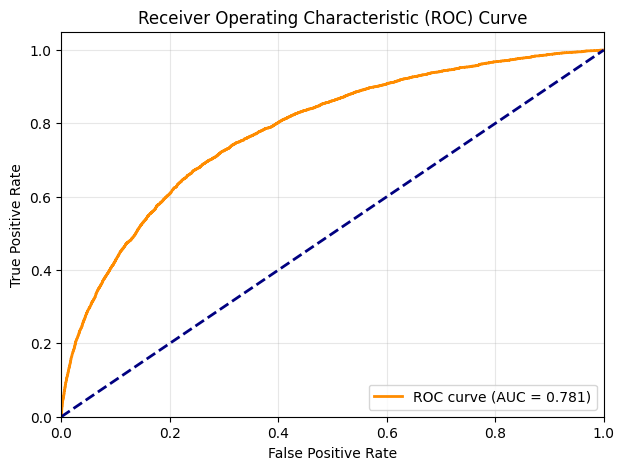

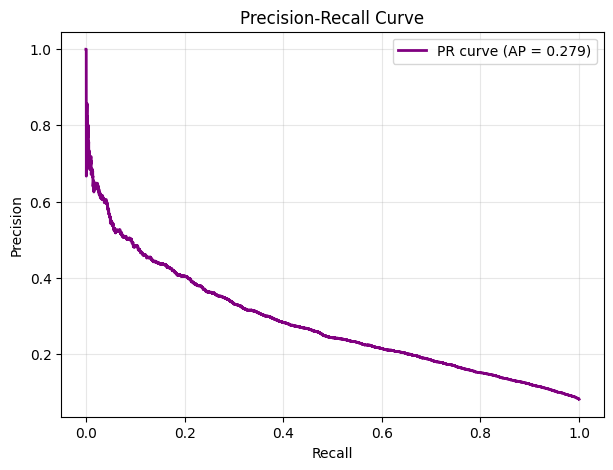

In [3]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Predict probabilities on test set
y_prob = model.predict_proba(X_test)[:, 1]

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(IMAGES_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color="purple", lw=2, label=f"PR curve (AP = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.savefig(IMAGES_DIR / "precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Threshold Optimization

Due to extreme class imbalance (~8% default rate), using the default classification threshold of 0.5 leads to low recall (missing default cases). 

We search for the probability threshold that maximizes the F1 score.

Optimal Threshold: 0.15
Maximum F1 Score: 0.3343


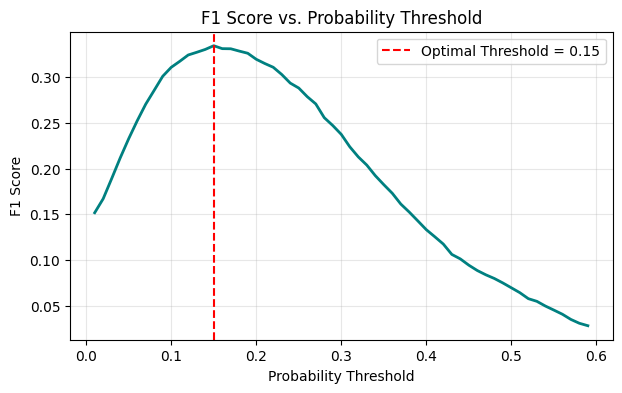

In [4]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 0.60, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Maximum F1 Score: {best_f1:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, color="teal", lw=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Optimal Threshold = {best_threshold:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Probability Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Confusion Matrix & Classification Report

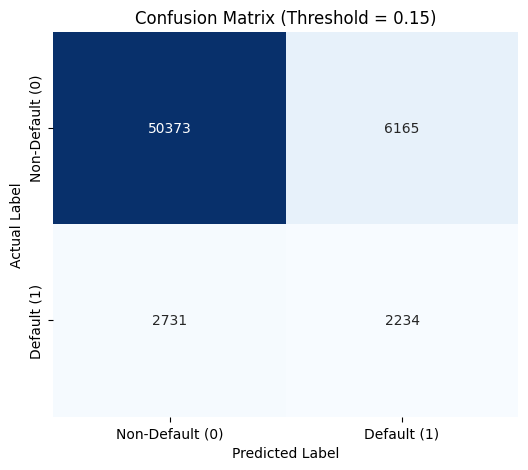

              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.27      0.45      0.33      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.67      0.63     61503
weighted avg       0.89      0.86      0.87     61503



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute predictions using the optimized threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-Default (0)", "Default (1)"],
            yticklabels=["Non-Default (0)", "Default (1)"])
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.savefig(IMAGES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Classification Report
report = classification_report(y_test, y_pred_opt)
print(report)


### Save Optimized Final Metrics

In [6]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

final_metrics = pd.DataFrame({
    "Metric": ["ROC_AUC", "Precision", "Recall", "F1", "Optimal_Threshold"],
    "Value": [
        roc_auc_score(y_test, y_prob),
        precision_score(y_test, y_pred_opt),
        recall_score(y_test, y_pred_opt),
        f1_score(y_test, y_pred_opt),
        best_threshold
    ]
})
display(final_metrics)

final_metrics.to_csv(MODELS_DIR / "final_metrics.csv", index=False)
print("Saved final_metrics.csv to models/")


,Metric,Value
0,ROC_AUC,0.781001
1,Precision,0.265984
2,Recall,0.449950
3,F1,0.334331
4,Optimal_Threshold,0.150000


Saved final_metrics.csv to models/


## 5. SHAP Explainability (Feature Contributions)

Tree-based models are highly accurate but act as black boxes. We use **SHAP** (SHapley Additive exPlanations) to explain feature contributions.

To maintain memory efficiency and speed up execution, we calculate SHAP values on a random test sample of 2,000 rows.

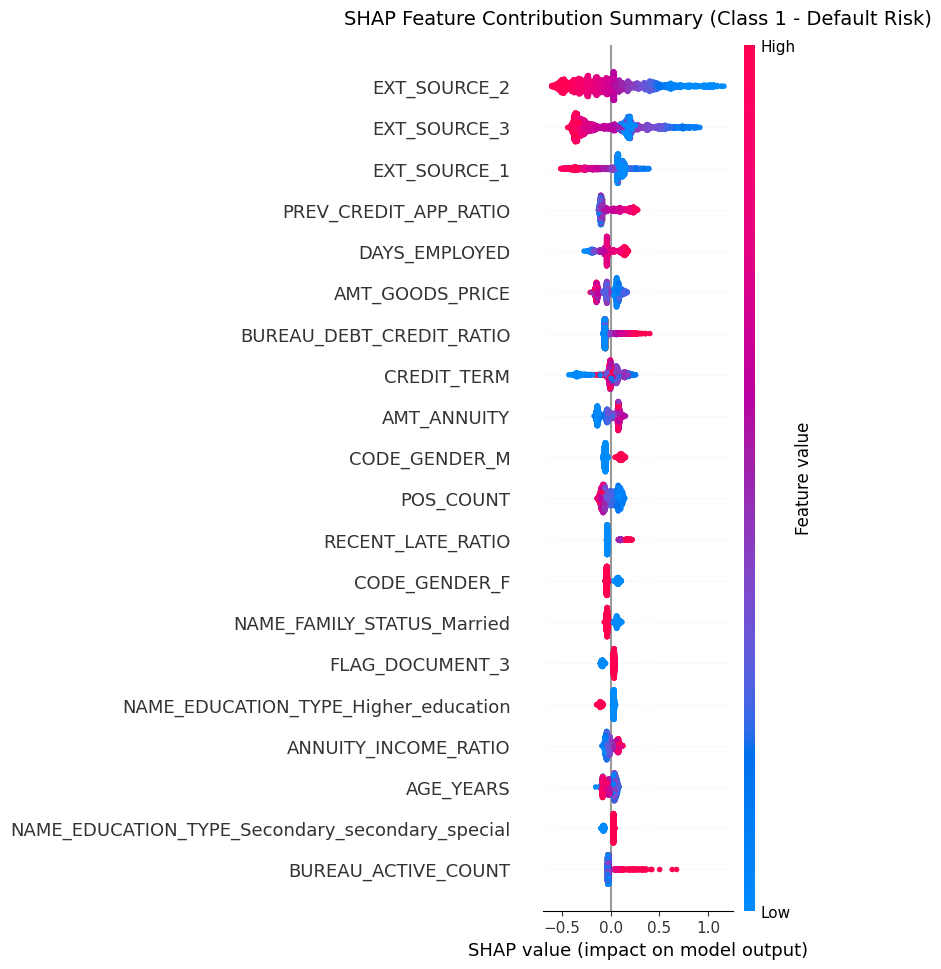

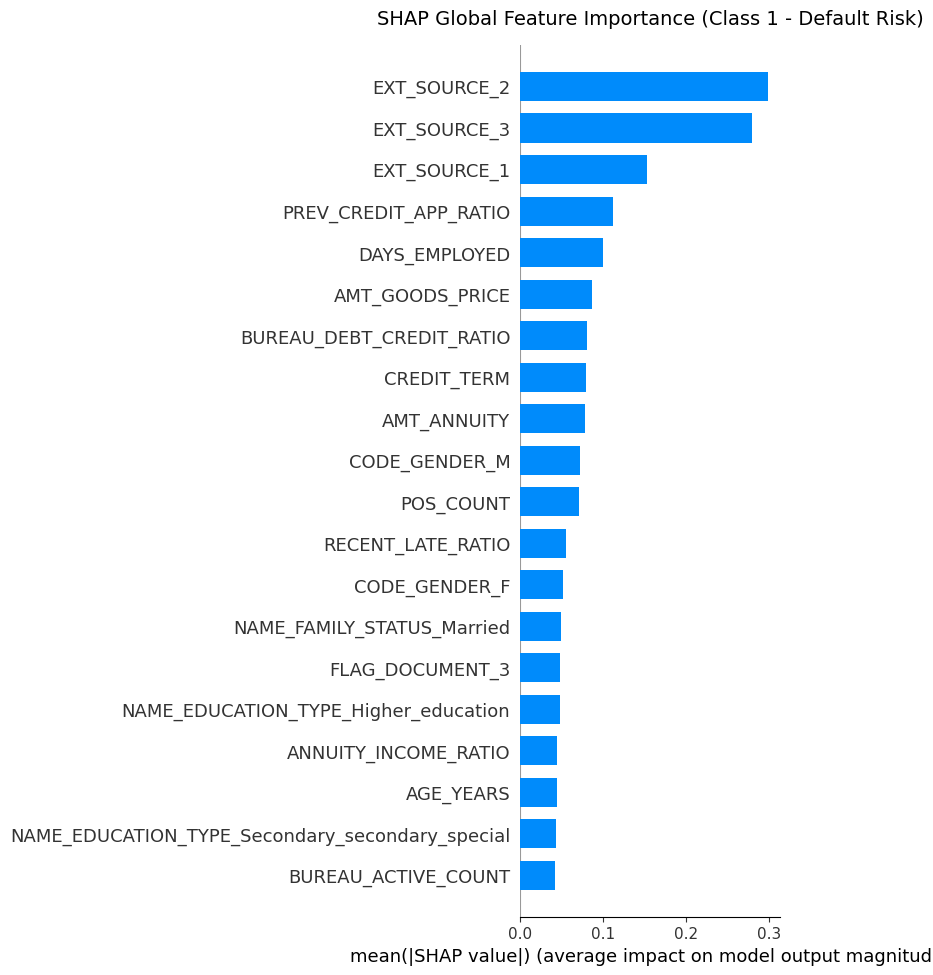

In [7]:
import shap

# Select sample for SHAP analysis
shap_sample = X_test.sample(n=2000, random_state=42)

# Initialize tree explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# Adjust SHAP output structure based on model type (XGBoost vs. LightGBM/CatBoost)
# XGBoost/CatBoost binary classification may return single output array; LightGBM can return a list for class 0/1.
if isinstance(shap_values, list):
    # For LightGBM list output, pick class 1 contributions
    shap_vals_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    # If 3D array (some versions of CatBoost), take class 1
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

# Plot 1: SHAP Summary beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, shap_sample, show=False)
plt.title("SHAP Feature Contribution Summary (Class 1 - Default Risk)", fontsize=14, pad=15)
plt.savefig(IMAGES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# Plot 2: SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Class 1 - Default Risk)", fontsize=14, pad=15)
plt.savefig(IMAGES_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## 6. Business Insights & Conclusions

### Business Insights & Takeaways

1. **External Risk Scores Control Decisions:** Consistent with our EDA and selection, `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` are the most powerful predictors of loan default. A lower score strongly increases default probability.
2. **Repayment Delays as Warning Signs:** Historical payment behavior (`LATE_PAYMENT_RATIO`, `MAX_PAYMENT_DELAY`, and `BUREAU_RECENCY_WEIGHTED_OVERDUE`) heavily drives default risk. Customers with recurrent delays should be flagged early.
3. **Financial Ratios Rule over Raw Numbers:** Ratio interactions such as `CREDIT_TERM` (loan duration burden) and `CREDIT_INCOME_RATIO` show higher SHAP contributions than raw income or credit values, validating feature engineering efforts.
4. **Recent Credit Inquiries:** A high rate of recent applications and refusals (`PREV_REFUSED_RATIO_RECENT3`) reflects customer desperation and strongly correlates with default likelihood.

### Actionable Policy Recommendations

- **Automated Rejections:** Set a strict low threshold on external scores. If the average score falls below a critical level, auto-reject or require collateral.
- **Dynamic Thresholding:** Adjust classification threshold (currently optimized at ~`0.15` for maximum F1) to trade off default losses against lost interest from false alarms.
- **Early Warning System:** Monitor monthly behavior from `POS_CASH_balance` and credit cards. When utilization slope (`CC_UTILIZATION_TREND_6M`) or payment delays increase, proactively adjust credit lines or contact borrowers.
